In [1]:
import torch
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle
import os
from nflows.distributions.normal import ConditionalDiagonalNormal, StandardNormal
from nflows.transforms.nonlinearities import PiecewiseRationalQuadraticCDF
from nflows.flows.base import Flow
from nflows.transforms.base import CompositeTransform, Transform
from nflows.transforms.autoregressive import MaskedPiecewiseRationalQuadraticAutoregressiveTransform, MaskedAffineAutoregressiveTransform

In [6]:
# importlib.reload(nugget.surrogates.LightSabre)
light_yield_patd_surrogate = nugget.surrogates.LightSabre.LightSabrePATD(use_poisson=True, num_track_points=1000, domain_size=2500, use_max_energy_dist=True).light_yield_surrogate
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(event_type='signal', domain_size=2500, E_min=1e2, E_max=1e8, energy_dist='log_uniform', find_exact_intersection=True)

Number of photons: 1327


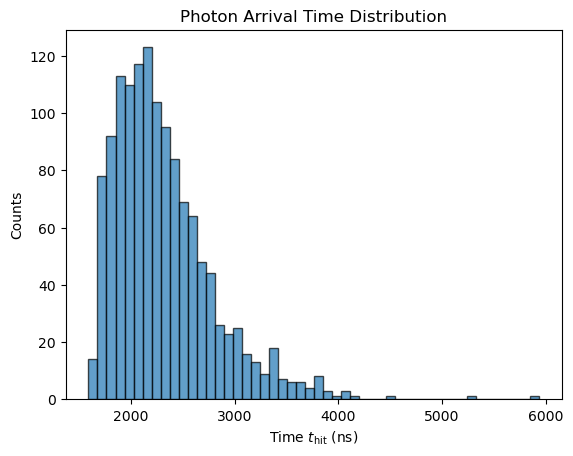

Photon arrival times max: 4346.982421875 ns


In [17]:
ly = 0
while ly < 1000:
    signal_event = signal_sampler.sample_events(1)  # Generate one signal event with physics parameters
    coordinate = signal_sampler.sample_detector_points(1)  # Sample a detector position
    patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=signal_event[0])
    ly = patd_dict['num_photons']
print(f"Number of photons: {patd_dict['num_photons']}")
plt.hist(patd_dict['hit_times'].cpu().numpy(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Photon Arrival Time Distribution')
plt.xlabel(r'Time $t_{\mathrm{hit}}$ (ns)')
plt.ylabel('Counts')
plt.show()
print(f"Photon arrival times max: {max(patd_dict['hit_times']) - min(patd_dict['hit_times'])} ns")

In [3]:
num_samples  = 1
signal_events = []
coordinates = []
for i in range(num_samples):    
    ly = 0
    while ly < 1000:
        signal_event = signal_sampler.sample_events(1)  # Generate one signal event with physics parameters
        coordinate = signal_sampler.sample_detector_points(1)  # Sample a detector position
        patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=signal_event[0])
        ly = patd_dict['num_photons']
    print(ly)
    signal_events.append(signal_event)
    coordinates.append(coordinate.squeeze(0))


7365


/ptmp/mpp/kristiantcho/nugget/nugget/surrogates/LightSabre.py:486: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474893324/work/aten/src/ATen/native/Cross.cpp:62.)
  t_foot = torch.norm(torch.cross(to_detector, track_dir))


In [69]:
def create_event_features(event_params, coordinate, num_hits, t_geom_min = None):
    energy = torch.log10(event_params['energy']).squeeze()
    x = coordinate[0] / 2500  # Scale x position
    y = coordinate[1] / 2500  # Scale y position
    z = coordinate[2] / 2500  # Scale z position
    v_x = event_params['position'][0][0]/2500
    v_y = event_params['position'][0][1]/2500
    v_z = event_params['position'][0][2]/2500
    d_x = event_params['direction'][0]
    d_y = event_params['direction'][1]
    d_z = event_params['direction'][2]
    log_hits = torch.log10(torch.tensor(num_hits, dtype=torch.float32))
    feature_list = [energy, x, y, z, v_x, v_y, v_z, d_x, d_y, d_z, log_hits]
    if t_geom_min is not None:
        feature_list.append(torch.log10(t_geom_min))
    features = torch.stack(feature_list).unsqueeze(0)
    features = features.repeat(int(num_hits), 1)
    return features

In [70]:
def sample_detector_features(event_params, min_hits=10, output_patd_dict=False):
    while True:
        coordinate = signal_sampler.sample_detector_points(1).squeeze(0)
        patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=event_params)
        num_hits = patd_dict['num_photons']
        if num_hits >= min_hits:
            break
    features = create_event_features(event_params, coordinate, num_hits,)
    # hit_times = patd_dict['hit_times'].unsqueeze(1)
    hit_times = patd_dict['hit_times'].unsqueeze(1) - min(patd_dict['hit_times']) + 1e-3
    # hit_times = torch.clamp(patd_dict['hit_times'].unsqueeze(1) - patd_dict['t_geom_min'], min=1e-3)
    if output_patd_dict:
        return features, hit_times, patd_dict
    else:
        return features, hit_times

In [71]:
class LogTransform(Transform):
    def forward(self, x, context=None):
        # x > 0
        y = torch.log10(x)
        log_det = -torch.log(x).sum(dim=-1)
        return y, log_det

    def inverse(self, y, context=None):
        x = 10**y
        log_det = y.sum(dim=-1)*np.log(10)
        return x, log_det

def make_autoregressive_rqs():
    return MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
        features=1,
        hidden_features=64,
        context_features=11,
        num_bins=8,
        tails="linear",
        tail_bound=4,
        activation=torch.nn.SiLU()
    )
# def make_autoregressive_affine():
#     return MaskedAffineAutoregressiveTransform(
#         features=1,
#         hidden_features=64,
#         context_features=10,
#         activation=torch.nn.SiLU()
#     )

base_dist = StandardNormal(shape=[1])
# Create a deeper context encoder network
# context_encoder = torch.nn.Sequential(
#     torch.nn.Linear(11, 64),
#     torch.nn.SiLU(),
#     torch.nn.Linear(64, 32),
#     torch.nn.SiLU(),
#     torch.nn.Linear(32, 2)
# )
# context_encoder = torch.nn.Linear(11, 2)  # Simpler context encoder for testing

# base_dist = ConditionalDiagonalNormal(
#     shape=[1], 
#     context_encoder=context_encoder
# )
transforms = [LogTransform()]
num_layers = 6
# for _ in range(num_layers):
#     # Add a rational quadratic spline transform with larger tail_bound to handle wide range
#     transform = PiecewiseRationalQuadraticCDF(shape=[1], tail_bound=6, tails='linear', num_bins=4)
#     transforms.append(transform)
for _ in range(num_layers):
    transforms.append(make_autoregressive_rqs())

transform = CompositeTransform(transforms)
flow = Flow(transform, base_dist)
optimizer = torch.optim.Adam(flow.parameters(), lr=0.5e-4)


In [72]:
num_iterations = 1200
all_test_samples = []
all_test_probs = []
max_batch_size = 800
for iteration in range(num_iterations):
    optimizer.zero_grad()
    all_log_probs = []
    # for i in range(num_samples):
        # signal_event = signal_events[i]
        # coordinate = coordinates[i]
        # with torch.no_grad():
    while len(all_log_probs) < max_batch_size:  
        features_batch, sample_times_raw = sample_detector_features(signal_event[0], min_hits=10)
            # sample_times_raw = light_yield_patd_surrogate(opt_point=coordinate, event_params=signal_event[0])['hit_times'].view(-1, 1)
            # features_batch = create_event_features(signal_event[0], coordinate, len(sample_times_raw))
        # Normalize to ~N(0,1) range for the flow
        # log_probs = flow.log_prob(sample_times_raw, context=features_batch.squeeze())
    # if len(sample_times_raw) == 0:
    #     continue 
        log_probs = flow.log_prob(sample_times_raw, context=features_batch)
        # for sample_time in sample_times_raw:
        #     log_probs = flow.log_prob(sample_time.unsqueeze(0), context=features_batch)
        all_log_probs.extend(log_probs)
    log_probs = torch.stack(all_log_probs[:], dim=0)
    loss = -log_probs.mean()
    loss.backward()
    optimizer.step()
    if (iteration) % 100 == 0 or iteration == num_iterations - 1:
        print(f"Iteration {iteration+1}/{num_iterations}, Loss: {loss.item():.4f}")
 

Iteration 1/1200, Loss: 17.9195
Iteration 101/1200, Loss: 7.1846
Iteration 201/1200, Loss: 6.6501
Iteration 301/1200, Loss: 6.9549
Iteration 401/1200, Loss: 6.7028
Iteration 501/1200, Loss: 6.5231
Iteration 601/1200, Loss: 6.8318
Iteration 701/1200, Loss: 6.6325


KeyboardInterrupt: 

In [63]:
len(sample_times_raw)

0

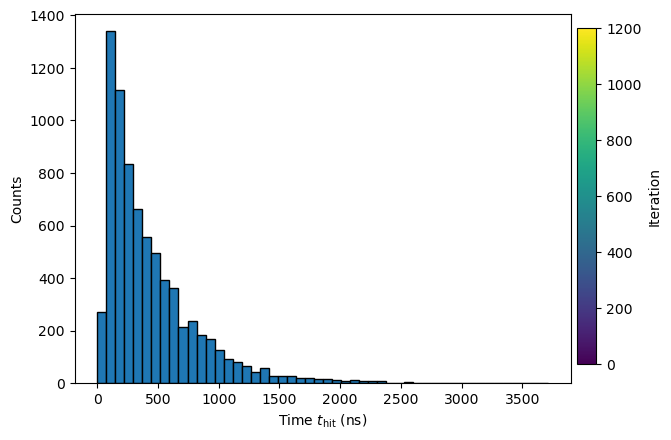

In [73]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

plt.hist(sample_times_raw.cpu().numpy(), bins=50, alpha=1, edgecolor='black', density=False, label='Original Data')

# Create a colormap and normalization
colormap = plt.get_cmap('viridis')

norm = Normalize(vmin=0, vmax=num_iterations)
sm = ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

# plot all the test samples colored by iteration
for i in range(len(all_test_samples)):
    if i == 0:
        continue
    iteration = i * 100 if i < len(all_test_samples) - 1 else num_iterations - 1
    color = colormap(norm(iteration))
    plt.hist(all_test_samples[i], bins=40, alpha=0.5, color=color)

plt.xlabel(r'Time $t_{\mathrm{hit}}$ (ns)')
plt.ylabel('Counts')
plt.colorbar(sm, label='Iteration', cax=plt.gcf().add_axes([0.91, 0.15, 0.03, 0.7]))
plt.show()


tensor(6081.0342, grad_fn=<UnbindBackward0>)


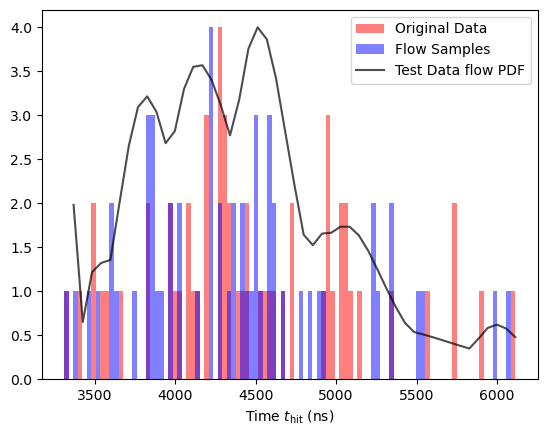

Charge of original data: 57, Charge of flow samples: 57
Min of original data: 3310.905029296875, Min of flow samples: 3312.457275390625


In [87]:

# sample_times_raw = torch.tensor([])
# while len(sample_times_raw) < 1:    
#     patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=signal_event[0])
#     sample_times_raw = patd_dict['hit_times'].view(-1, 1)
features_batch, sample_times_raw, patd_dict = sample_detector_features(signal_event[0], min_hits=10, output_patd_dict=True)
samples = flow.sample(len(sample_times_raw.squeeze()), context=features_batch[0].unsqueeze(0)) + min(patd_dict['hit_times'])
print(max(samples.squeeze()))
# sample_times_raw += min(patd_dict['hit_times'])
sample_times_raw += min(patd_dict['hit_times']) 
# samples = samples[samples<1e4]
# do not include any samples further than 2 sigma of the original data
# samples = samples[(samples < samples.mean() + 5*samples.std())] 
# samples = samples[samples>=min(sample_times_raw)]
# samples = samples[samples<=max(sample_times_raw)] 
counts, bin_edges = np.histogram(sample_times_raw.detach().numpy(), bins=100)
plt.stairs(counts, bin_edges, label='Original Data', color='red', alpha=0.5, edgecolor='black', fill=True)
pred_counts, _ = np.histogram(samples.detach().numpy(), bins=bin_edges)
plt.stairs(pred_counts, bin_edges, label='Flow Samples', color='blue', alpha=0.5, edgecolor='black', fill=True)
# plt.hist(bin_edges[:-1], bin_edges, weights=counts, label='Original Data', color='red',density=True, alpha=0.5, edgecolor='red')
# plt.hist(samples.squeeze().detach().numpy(), bins=bin_edges, edgecolor='blue', density=True, alpha=0.5, label='Flow Samples', color='blue')
# plt.hist(samples.squeeze().detach().numpy(), bins=50, edgecolor='blue', density=False, alpha=0.5, label='Flow Samples', color='blue')
# plt.hist(sample_times_raw.detach().numpy(), bins=100, edgecolor='red', density=False, alpha=0.5, label='Original Data', color='red')
# samples = torch.tensor(torch.sort(samples)).view(-1, 1)
test_sample_times = np.linspace(sample_times_raw.min().detach().numpy(), sample_times_raw.max().detach().numpy(), 50).reshape(-1, 1)
new_features = np.repeat(features_batch[0].unsqueeze(0).detach().numpy(), 50, axis=0)
probs = np.exp(flow.log_prob(test_sample_times-min(patd_dict['hit_times']).detach().numpy(), context = new_features).detach().numpy())
plt.plot(sorted(test_sample_times[1:]), (probs[1:])/max(probs[1:])*np.max((counts, pred_counts)), color='k', label='Test Data flow PDF', alpha=0.7)
plt.xlabel(r'Time $t_{\mathrm{hit}}$ (ns)')
plt.legend()
plt.show()
print(f"Charge of original data: {sum(counts)}, Charge of flow samples: {sum(pred_counts)}")
print(f"Min of original data: {sample_times_raw.min()}, Min of flow samples: {samples.min()}")


In [18]:
importlib.reload(nugget.surrogates.HitFlow)
hitflow = nugget.surrogates.HitFlow.HitFlow(
    domain_size=2500,  # Size of the detector domain
    dim=3,  # 3D spatial coordinates
    hidden_features=64,  # Neural network architecture
    num_bins=10,  # Number of bins for PiecewiseRationalQuadraticCDF
    tail_bound=4,  # Tail bound for spline transforms
    vary_cylinder=True,  # Vary cylinder size during training
    min_domain_size=2500*0.01,  # Minimum cylinder size
    max_domain_size=2500,  # Maximum cylinder size  
)

hitflow.load_model('best_hitflow_model_v4')

tensor(6963.6914)


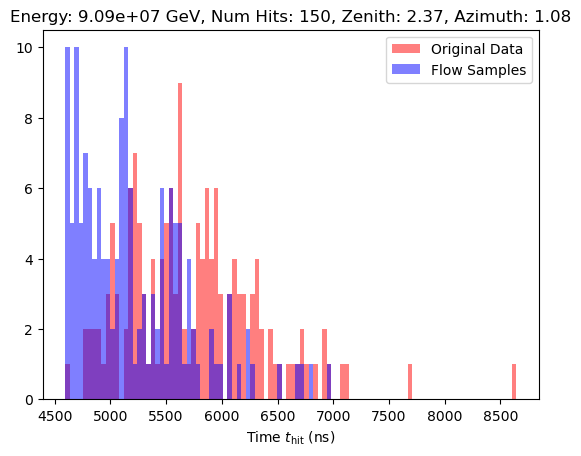

Charge of original data: 150, Charge of flow samples: 150
Min of original data: 4593.71142578125, Min of flow samples: 4593.71240234375


In [52]:
# sample_times_raw = torch.tensor([])
# while len(sample_times_raw) < 1:    
#     patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=signal_event[0])
#     sample_times_raw = patd_dict['hit_times'].view(-1, 1)
  # Generate one signal event with physics parameters
min_hits = 10
while True:
  event_params = signal_sampler.sample_events(1)[0]
  counter = 0
  while True:
      coordinate = signal_sampler.sample_detector_points(1).squeeze(0)
      patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=event_params)
      num_hits = patd_dict['num_photons']
      if num_hits >= min_hits:
          break
      counter += 1
      if counter >= 1000:
          break
  if num_hits >= min_hits:
    break
samples_dict = hitflow.light_yield_surrogate(event_params=event_params, opt_point=coordinate, light_yield=num_hits, min_hit_time=min(patd_dict['hit_times']))
samples = samples_dict['hit_times'].unsqueeze(1)
print(max(samples.squeeze()))
sample_times_raw = patd_dict['hit_times'].unsqueeze(1)

# samples = samples[(samples < samples.mean() + 5*samples.std())] 

counts, bin_edges = np.histogram(sample_times_raw.detach().numpy(), bins=100)
plt.stairs(counts, bin_edges, label='Original Data', color='red', alpha=0.5, edgecolor='black', fill=True)
pred_counts, _ = np.histogram(samples.detach().numpy(), bins=bin_edges)
plt.stairs(pred_counts, bin_edges, label='Flow Samples', color='blue', alpha=0.5, edgecolor='black', fill=True)
# plt.hist(bin_edges[:-1], bin_edges, weights=counts, label='Original Data', color='red',density=True, alpha=0.5, edgecolor='red')
# plt.hist(samples.squeeze().detach().numpy(), bins=bin_edges, edgecolor='blue', density=True, alpha=0.5, label='Flow Samples', color='blue')
# plt.hist(samples.squeeze().detach().numpy(), bins=50, edgecolor='blue', density=False, alpha=0.5, label='Flow Samples', color='blue')
# plt.hist(sample_times_raw.detach().numpy(), bins=100, edgecolor='red', density=False, alpha=0.5, label='Original Data', color='red')
# samples = torch.tensor(torch.sort(samples)).view(-1, 1)
# test_sample_times = np.linspace(sample_times_raw.min().detach().numpy(), sample_times_raw.max().detach().numpy(), 50).reshape(-1, 1)
# new_features = np.repeat(features_batch[0].unsqueeze(0).detach().numpy(), 50, axis=0)
# probs = np.exp(flow.log_prob(test_sample_times-min(patd_dict['hit_times']).detach().numpy(), context = new_features).detach().numpy())
# plt.plot(sorted(test_sample_times[1:]), (probs[1:])/max(probs[1:])*np.max((counts, pred_counts)), color='k', label='Test Data flow PDF', alpha=0.7)
plt.xlabel(r'Time $t_{\mathrm{hit}}$ (ns)')
plt.legend()
plt.title(f'Energy: {event_params["energy"].item():.2e} GeV, Num Hits: {num_hits}, Zenith: {event_params["zenith"].item():.2f}, Azimuth: {event_params["azimuth"].item():.2f}')
plt.show()

print(f"Charge of original data: {sum(counts)}, Charge of flow samples: {sum(pred_counts)}")
print(f"Min of original data: {sample_times_raw.min()}, Min of flow samples: {samples.min()}")

In [53]:
pred_dict = hitflow.evaluate_pdf(hit_times=sample_times_raw.squeeze(), event_params=event_params, opt_point=coordinate, min_hit_time=min(patd_dict['hit_times']))
pred_probs = pred_dict['log_probs'].detach().cpu().numpy()
pred_probs = np.exp(pred_probs)
true_probs = nugget.surrogates.cpandel.cpandel._pdf(
    t=patd_dict["residual_times"].detach().cpu().numpy(), d=patd_dict["d_geom"].detach().cpu().numpy())

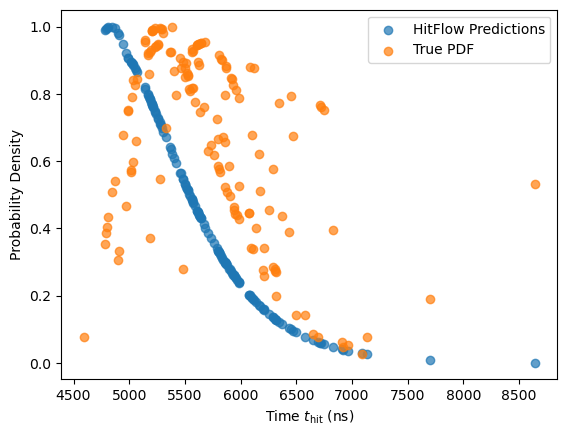

In [54]:
sorted_inds = np.argsort(patd_dict['hit_times'].detach().cpu().numpy())
plt.scatter(patd_dict["hit_times"].detach().cpu().numpy()[sorted_inds][pred_probs[sorted_inds] <= 1], pred_probs[sorted_inds][pred_probs[sorted_inds] <= 1]/max(pred_probs[pred_probs <= 1]), alpha=0.7, label='HitFlow Predictions')
plt.scatter(patd_dict["hit_times"].detach().cpu().numpy()[sorted_inds], true_probs[sorted_inds]/max(true_probs), alpha=0.7, label='True PDF')
plt.xlabel(r'Time $t_{\mathrm{hit}}$ (ns)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [32]:
# Check if CUDA is available
print(torch.cuda.is_available())

# Get number of GPUs
print(torch.cuda.device_count())

# Get current GPU device
print(torch.cuda.current_device())

# Get GPU device name
print(torch.cuda.get_device_name(0))  # 0 is the device index

# Get all GPU names
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

True
4
0
NVIDIA A100-SXM4-40GB
GPU 0: NVIDIA A100-SXM4-40GB
GPU 1: NVIDIA A100-SXM4-40GB
GPU 2: NVIDIA A100-SXM4-40GB
GPU 3: NVIDIA A100-SXM4-40GB
